In [94]:
%reset -f

In [95]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.dates import YearLocator, MonthLocator, DateFormatter
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerLine2D
from matplotlib.lines import Line2D

In [96]:
os.chdir(r'C:\Users\ANDILATT\OneDrive\Data_analysis')

In [74]:
#load all datasets
#
df2 = pd.read_excel("Data_source_paper_biogeosciences.xlsx", sheet_name="SimREF")
df2["time_counter"] = pd.to_datetime(df2["time_counter"])
df2 = df2[df2["time_counter"].dt.year < 2024]
df2.set_index("time_counter", inplace=True)
df2.head()

,Rain,LAI_Tree_obs,LAI_Tree_orch,LAI_Crop_obs,LAI_Crop_orch,GPP_Crop_obs,GPP_Crop_orch,GPP_Tree_obs,GPP_Tree_orch,GPP_ecosys_obs,...,LE_ecosys_orch,H_ecosys_orch,Rn_ecosys_orch,LE_ecosys_obs,H_ecosys_obs,Rn_ecosys_obs,Reco_ecosys_obs,Ra_ecosys_orch,Rh_ecosys_orch,Sum_Ra_Rh_ecosys_orch
time_counter,,,,,,,,,,,,,,,,,,,,,
2018-01-01,0.0,NaN,0.672373,0.0,0.0,0.0,0.0,1.714588,1.479819,1.714588,...,2.016498,4.256214,6.634872,NaN,NaN,NaN,0.602699,0.793178,2.253163,3.046341
2018-01-02,0.0,NaN,0.672373,0.0,0.0,0.0,0.0,1.723420,2.219343,1.723420,...,2.567095,3.002996,5.173116,NaN,NaN,NaN,0.606018,0.783767,2.191680,2.975447
2018-01-03,0.0,NaN,0.672373,0.0,0.0,0.0,0.0,1.727992,2.117901,1.727099,...,2.544828,3.260405,5.600364,NaN,NaN,NaN,0.608301,0.775032,2.176008,2.951039
2018-01-04,0.0,NaN,0.672373,0.0,0.0,0.0,0.0,1.715338,1.638381,1.701534,...,2.116358,4.338304,6.999491,NaN,NaN,NaN,0.611492,0.835509,2.167016,3.002525
2018-01-05,0.0,NaN,0.672373,0.0,0.0,0.0,0.0,1.713941,1.227810,1.713941,...,1.482193,2.381278,3.673648,NaN,NaN,NaN,0.600034,0.797663,2.181874,2.979537


In [82]:
import numpy as np
import pandas as pd
from scipy.stats import linregress

def calculate_r_squared(df, obs_col, sim_col):
    """
    Calculates the R-squared between two columns of a Pandas DataFrame.

    Args:
        df: The DataFrame containing the data.
        obs_col: The name of the observation column.
        sim_col: The name of the predicted column.

    Returns:
        The R-squared value.
    """

    # Extract relevant data, handling NaN values
    df = df.dropna(subset=[obs_col, sim_col])
    obs_y = df[obs_col].values
    sim_y = df[sim_col].values

    # Check for sufficient data points
    if len(obs_y) < 2 or len(sim_y) < 2:
        return np.nan  # Return NaN if there's insufficient data

    # Calculate linear regression and R-squared
    slope, intercept, r_value, _, _ = linregress(obs_y, sim_y)
    r_squared = r_value**2
    
    # Calculate RMSE
    rmse = np.sqrt(np.mean((obs_y - sim_y)**2))
    
    count = len(obs_y)

    return r_squared, rmse, count

In [83]:
# Define the calibration and validation periods
calibration_start = pd.Timestamp('2018-01-01')
calibration_end = pd.Timestamp('2020-12-31')
validation_start = pd.Timestamp('2021-01-01')
validation_end = pd.Timestamp('2023-12-31')

# Create sub datasets for calibration and validation periods
calibration_data = df2[(df2.index >= calibration_start) & (df2.index <= calibration_end)]
validation_data = df2[(df2.index >= validation_start) & (df2.index <= validation_end)]

In [84]:
# Define a list of dataframes and a list of column pairs
dataframes = [calibration_data, validation_data]
column_pairs = [('LAI_Tree_obs', 'LAI_Tree_orch'), ('LAI_Crop_obs', 'LAI_Crop_orch'),
                 ('GPP_Tree_obs', 'GPP_Tree_orch'), ('GPP_Crop_obs', 'GPP_Crop_orch'),
                 ('GPP_ecosys_obs', 'GPP_ecosys_orch'), ('NEE_ecosys_obs', 'NEE_ecosys_orch'),
                 ('LE_ecosys_obs', 'LE_ecosys_orch'), ('H_ecosys_obs', 'H_ecosys_orch'),
                 ('Rn_ecosys_obs', 'Rn_ecosys_orch')]

# Create an empty dictionary to store the results
results = {}

# Iterate over dataframes and column pairs
for df in dataframes:
    for col1, col2 in column_pairs:
        r_squared_result, rmse, count = calculate_r_squared(df, col1, col2)
        data_type = "Calibration" if df is calibration_data else "Validation"
        key = f"{data_type} {col1[:-4]}"
        results[key] = {"R-squared": r_squared_result, "RMSE": rmse, "N": count}

# Print the results from the dictionary
for key, value in results.items():
    print(f"{key} ===> R-squared: {value['R-squared']:.4f}; RMSE: {value['RMSE']:.4f}; N: {count}")

Calibration LAI_Tree ===> R-squared: 0.7746; RMSE: 0.2926; N: 1095
Calibration LAI_Crop ===> R-squared: 0.4046; RMSE: 0.2969; N: 1095
Calibration GPP_Tree ===> R-squared: 0.1853; RMSE: 0.9633; N: 1095
Calibration GPP_Crop ===> R-squared: 0.7689; RMSE: 1.7528; N: 1095
Calibration GPP_ecosys ===> R-squared: 0.7540; RMSE: 1.5111; N: 1095
Calibration NEE_ecosys ===> R-squared: 0.1977; RMSE: 2.8751; N: 1095
Calibration LE_ecosys ===> R-squared: 0.6458; RMSE: 1.9054; N: 1095
Calibration H_ecosys ===> R-squared: 0.6460; RMSE: 2.5581; N: 1095
Calibration Rn_ecosys ===> R-squared: 0.6758; RMSE: 3.0019; N: 1095
Validation LAI_Tree ===> R-squared: 0.8982; RMSE: 0.2574; N: 1095
Validation LAI_Crop ===> R-squared: 0.5795; RMSE: 0.2650; N: 1095
Validation GPP_Tree ===> R-squared: 0.1572; RMSE: 0.9737; N: 1095
Validation GPP_Crop ===> R-squared: 0.7569; RMSE: 1.7959; N: 1095
Validation GPP_ecosys ===> R-squared: 0.6210; RMSE: 1.8450; N: 1095
Validation NEE_ecosys ===> R-squared: 0.0364; RMSE: 3.0157;

In [93]:
for key, value in results.items():
    if "Validation" in key:
        print(f"{key}: RMSE = {value['RMSE']}, R-squared = {value['R-squared']}")


Validation LAI_Tree: RMSE = 0.25737858714136647, R-squared = 0.8982023848453276
Validation LAI_Crop: RMSE = 0.2649763052684512, R-squared = 0.5795372585010017
Validation GPP_Tree: RMSE = 0.9737442643561256, R-squared = 0.15721618563641662
Validation GPP_Crop: RMSE = 1.7959242970655898, R-squared = 0.7568973280687218
Validation GPP_ecosys: RMSE = 1.8450424114037436, R-squared = 0.6210458036376978
Validation NEE_ecosys: RMSE = 3.0156874853936713, R-squared = 0.0363542876929362
Validation LE_ecosys: RMSE = 2.1247407513881047, R-squared = 0.48611926598602717
Validation H_ecosys: RMSE = 2.402088414918573, R-squared = 0.6684699907564401
Validation Rn_ecosys: RMSE = 2.3110141506782376, R-squared = 0.7240239707173654


In [90]:
for n in column_pairs:
    n_count = validation_data.dropna(subset=list(n)).shape[0]
    print (n, n_count)


('LAI_Tree_obs', 'LAI_Tree_orch') 365
('LAI_Crop_obs', 'LAI_Crop_orch') 334
('GPP_Tree_obs', 'GPP_Tree_orch') 666
('GPP_Crop_obs', 'GPP_Crop_orch') 1095
('GPP_ecosys_obs', 'GPP_ecosys_orch') 1095
('NEE_ecosys_obs', 'NEE_ecosys_orch') 1095
('LE_ecosys_obs', 'LE_ecosys_orch') 1095
('H_ecosys_obs', 'H_ecosys_orch') 1095
('Rn_ecosys_obs', 'Rn_ecosys_orch') 1095


In [ ]:
validation_data.dropna(subset=['LAI_Tree_obs', 'LAI_Tree_orch']).shape[0]

### Plot LAI

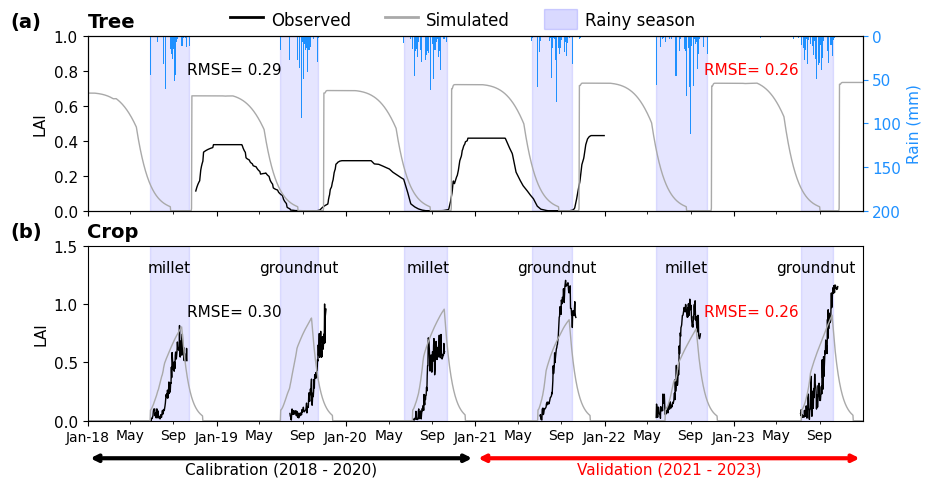

In [215]:


# Define color
color_obs = 'black'
color_sim = 'darkgrey'
color_rain = '#1E90FF'
line_weight = 1

# Identify the start and end dates for the rainy season each year
rainy_seasons = []
for year, group in df2.groupby(df2.index.year):
    first_rain_dates = group[group['Rain'] > 5].index
    last_rain_dates = group[group['Rain'] > 5].index
    if not first_rain_dates.empty:
        start_date = first_rain_dates.min()
        end_date = last_rain_dates.max()
        rainy_seasons.append((start_date, end_date))

# Create the plots with shared x-axis
fig, (ax2, ax1) = plt.subplots(2, 1, sharex=True, figsize=(10, 5))

# Add the inverted Rain on the secondary y-axis
ax3 = ax2.twinx()
ax3.invert_yaxis()
ax3.bar(df2.index, df2['Rain'], width=3, color=color_rain, label='Rain (mm)')

# Highlight the rainy periods
for start, end in rainy_seasons:
    ax1.axvspan(start, end, color='blue', alpha=0.1)
    ax2.axvspan(start, end, color='blue', alpha=0.1)

# Plot LAI_Crop_obs and LAI_Crop_orch on the first subplot
ax1.plot(df2.index, df2['LAI_Crop_obs'], lw=line_weight, label='LAI_Crop_obs', color=color_obs)
ax1.plot(df2.index, df2['LAI_Crop_orch'], lw=line_weight, label='LAI_Crop_orch', color=color_sim)

# Add crop annotations at June 1st
crops = ['millet', 'groundnut']  # Cycle through these crops
years = df2.index.year.unique()

for i, year in enumerate(years):
    crop = crops[i % len(crops)]  # Alternate between 'millet' and 'peanut'
    date = pd.Timestamp(f'{year}-08-20')
    ax1.text(date, 1.25, crop, color='black', fontsize=11, verticalalignment='bottom', horizontalalignment='center')


a_lim = df2.index.min() + pd.Timedelta(days=280)
b_lim = df2.index.max() - pd.Timedelta(days=180)
# Add MRMSE indicators
#Crop
ax1.text(a_lim, 1, f"RMSE= {results['Calibration LAI_Crop']['RMSE']:.2f}",
         color='black', fontsize=11, va='top', ha='left')
ax1.text(b_lim, 1, f"RMSE= {results['Validation LAI_Crop']['RMSE']:.2f}",
         color='red', fontsize=11, va='top', ha='right')
#Tree
ax2.text(a_lim, 0.85, f"RMSE= {results['Calibration LAI_Tree']['RMSE']:.2f}",
         color='black', fontsize=11, va='top', ha='left')
ax2.text(b_lim, 0.85, f"RMSE= {results['Validation LAI_Tree']['RMSE']:.2f}",
         color='red', fontsize=11, va='top', ha='right')

ax2.text(-0.1, 1.05, f'({chr(98)})', transform=ax1.transAxes, size=14, weight='bold')
ax1.text(-0.1, 1.05, f'({chr(97)})', transform=ax2.transAxes, size=14, weight='bold')
ax1.set_title("Crop", fontsize=14, loc="left", weight='bold')
ax2.set_title("Tree", fontsize=14, loc="left", weight='bold')

# Set labels and title for the first subplot
ax1.set_ylabel('LAI', fontsize=11)
ax3.set_ylabel('Rain (mm)', color=color_rain, fontsize=11)
ax3.tick_params(axis='y', colors=color_rain, labelsize=11)
ax3.set_ylim(200, 0)
ax1.set_ylim(0, 1.5)
ax2.set_ylim(0, 1)

# Plot LAI_Tree_obs and LAI_Tree_orch on the second subplot
line1, = ax2.plot(df2.index, df2['LAI_Tree_obs'], lw=line_weight, label='Observed', color=color_obs)
line2, = ax2.plot(df2.index, df2['LAI_Tree_orch'], lw=line_weight, label='Simulated', color=color_sim)

# Set labels and title for the second subplot
# ax2.set_xlabel('Date')
ax2.set_ylabel('LAI', fontsize=11)

# Create a patch for the rainy season
rain_patch = Patch(color='blue', alpha=0.15, label='Rainy season')

# Create lines for 'Observed' and 'Simulated'
line1 = Line2D([0], [0], color=color_obs, lw=2, label='Observed')  # lw (linewidth) = 2 for smaller line width
line2 = Line2D([0], [0], color=color_sim, lw=2, label='Simulated')

# Add a legend for the lines and patch
fig.legend([line1, line2, rain_patch],
           ['Observed', 'Simulated', 'Rainy season'],
           loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.95), frameon=False, 
           fontsize=12,
           handlelength=2,         
           handleheight=1.5,       
           labelspacing=2.0,       
           borderpad=0.0,          
           handletextpad=0.5)


ax1.set_xlim(df2.index.min(), df2.index.max())
ax2.set_xlim(df2.index.min(), df2.index.max())

# Set x-axis ticks for Jan, May, and Sept
ax2.xaxis.set_major_locator(YearLocator())
ax2.xaxis.set_minor_locator(MonthLocator(bymonth=[1, 5, 9]))
ax2.xaxis.set_major_formatter(DateFormatter("%Y"))
ax2.xaxis.set_minor_formatter(DateFormatter("%b"))
# ax1.set_xlabel('Date', fontsize=11)

# Update tick label sizes
ax2.tick_params(axis='x', which='major', labelsize=9)
ax2.tick_params(axis='x', which='minor', labelsize=8)
ax2.tick_params(axis='y', labelsize=11)
ax1.tick_params(axis='y', labelsize=11)

# Date formatter for minor ticks
date_form = DateFormatter("%b-%y")
ax2.xaxis.set_major_formatter(date_form)

# Create an additional axes at the bottom for drawing the arrows
bbox = ax1.get_position()
arrow_ax = fig.add_axes([bbox.x0, 0.01, bbox.width, 0.05])  # Align with ax1
arrow_ax.axis('off')

# Define start and end dates for the arrows
start_date_black = pd.Timestamp('2018-01-01')
end_date_black = pd.Timestamp('2020-12-31')
start_date_red = pd.Timestamp('2021-01-01')
end_date_red = pd.Timestamp('2023-12-31')

# Draw arrows using date positions directly on the new axis
arrow_ax.annotate('', xy=(start_date_black, 0.5), xytext=(end_date_black, 0.5),
                  arrowprops=dict(arrowstyle='<->', color='black', linewidth=3),
                  xycoords='data', textcoords='data', annotation_clip=False)

arrow_ax.annotate('', xy=(start_date_red, 0.5), xytext=(end_date_red, 0.5),
                  arrowprops=dict(arrowstyle='<->', color='red', linewidth=3),
                  xycoords='data', textcoords='data', annotation_clip=False)

# Compute the midpoints and add text below the arrows
mid_black = start_date_black + (end_date_black - start_date_black) / 2
mid_red = start_date_red + (end_date_red - start_date_red) / 2

arrow_ax.text(mid_black, 0.05, 'Calibration (2018 - 2020)',
              color='black', ha='center', va='center', fontsize=11)

arrow_ax.text(mid_red, 0.05, 'Validation (2021 - 2023)',
              color='red', ha='center', va='center', fontsize=11)

arrow_ax.set_xlim(df2.index.min(), df2.index.max())

plt.show()

### Plot GPP

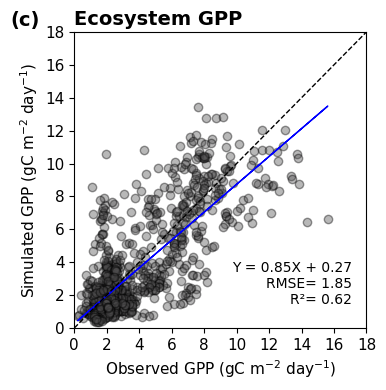

In [228]:

# Calculate statistics
obs = validation_data['GPP_ecosys_obs']
sim = validation_data['GPP_ecosys_orch']


# Plotting
fig, ax = plt.subplots(figsize=(4, 4))

ax.scatter(obs, sim, color="#4f4e4f", alpha=0.4, edgecolor='black')

# Line of best fit
slope, intercept, r_value, p_value, std_err = linregress(obs, sim)


ax.plot(obs, slope * obs + intercept, color="blue", linewidth=1)

ax.plot([0, 18], [0, 18], 'k--', lw=1)

sign = '-' if intercept < 0 else '+'

# Additional metrics text
metrics_text = f"Y = {slope:.2f}X {sign} {abs(intercept):.2f}\n"\
                f"RMSE= {results['Validation GPP_ecosys']['RMSE']:.2f}\n" \
                f"R²= {results['Validation GPP_ecosys']['R-squared']:.2f}"

ax.text(0.95, 0.07, metrics_text, fontsize=10, va='bottom', ha='right', 
        transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

ax.text(-0.22, 1.02, f'({chr(99)})', transform=ax.transAxes, size=14, weight='bold')


# Labels and title

ax.set_xlabel('Observed GPP (gC m$^{-2}$ day$^{-1}$)', fontsize=11)
ax.set_ylabel('Simulated GPP (gC m$^{-2}$ day$^{-1}$)', fontsize=11)
ax.set_title('Ecosystem GPP', loc='left', pad=5, size=14, weight='bold')
ax.set_xlim([0, 18])
ax.set_ylim([0, 18])
ax.set_xticks(np.arange(0, 19, 2)) 
ax.set_yticks(np.arange(0, 19, 2))
ax.tick_params(axis='both', labelsize=11)
plt.tight_layout()
plt.show()


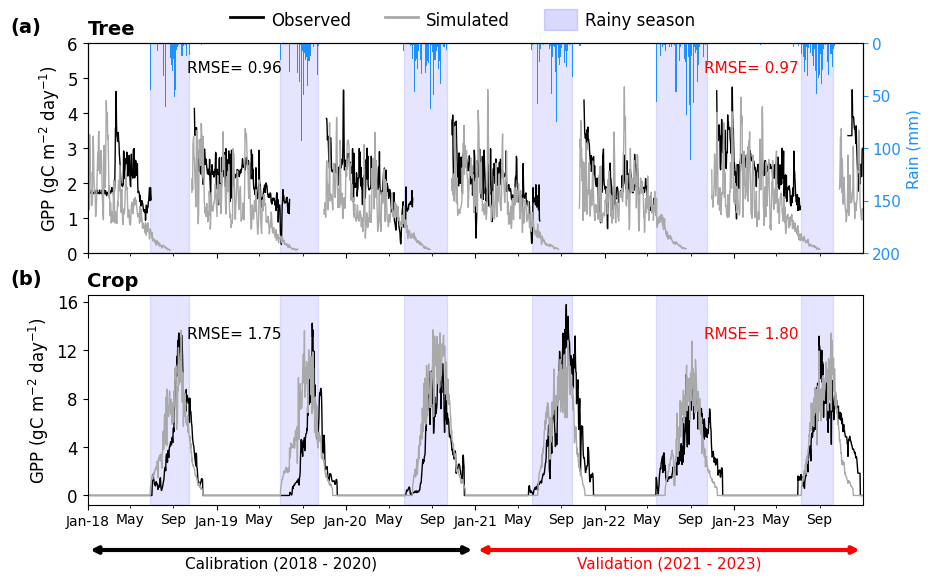

In [39]:


# Define color
color_obs = 'black'
color_sim = 'darkgrey'
color_rain = '#1E90FF'
line_weight = 1

# Identify the start and end dates for the rainy season each year
rainy_seasons = []
for year, group in df2.groupby(df2.index.year):
    first_rain_dates = group[group['Rain'] > 5].index
    last_rain_dates = group[group['Rain'] > 5].index
    if not first_rain_dates.empty:
        start_date = first_rain_dates.min()
        end_date = last_rain_dates.max()
        rainy_seasons.append((start_date, end_date))

# Create the plots with shared x-axis
fig, (ax2, ax1) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))

# Add the inverted Rain on the secondary y-axis
ax3 = ax2.twinx()
ax3.invert_yaxis()
ax3.bar(df2.index, df2['Rain'], width=3, color=color_rain, label='Rain (mm)')

# Highlight the rainy periods
for start, end in rainy_seasons:
    ax1.axvspan(start, end, color='blue', alpha=0.1)
    ax2.axvspan(start, end, color='blue', alpha=0.1)

# Plot LAI_Crop_obs and LAI_Crop_orch on the first subplot
ax1.plot(df2.index, df2['GPP_Crop_obs'], lw=line_weight, color=color_obs)
ax1.plot(df2.index, df2['GPP_Crop_orch'], lw=line_weight, color=color_sim)

# # Add crop annotations at June 1st
# crops = ['millet', 'groundnut']  # Cycle through these crops
# years = df2.index.year.unique()

# for i, year in enumerate(years):
#     crop = crops[i % len(crops)]  # Alternate between 'millet' and 'peanut'
#     date = pd.Timestamp(f'{year}-08-20')
#     ax1.text(date, 1.25, crop, color='black', fontsize=11, verticalalignment='bottom', horizontalalignment='center')


a_lim = df2.index.min() + pd.Timedelta(days=280)
b_lim = df2.index.max() - pd.Timedelta(days=180)
# Add MRMSE indicators
#Crop
ax1.text(a_lim, 14, f"RMSE= {results['Calibration GPP_Crop']['RMSE']:.2f}",
         color='black', fontsize=11, va='top', ha='left')
ax1.text(b_lim, 14, f"RMSE= {results['Validation GPP_Crop']['RMSE']:.2f}",
         color='red', fontsize=11, va='top', ha='right')
#Tree
ax2.text(a_lim, 5.5, f"RMSE= {results['Calibration GPP_Tree']['RMSE']:.2f}",
         color='black', fontsize=11, va='top', ha='left')
ax2.text(b_lim, 5.5, f"RMSE= {results['Validation GPP_Tree']['RMSE']:.2f}",
         color='red', fontsize=11, va='top', ha='right')

ax2.text(-0.1, 1.05, f'({chr(98)})', transform=ax1.transAxes, size=14, weight='bold')
ax1.text(-0.1, 1.05, f'({chr(97)})', transform=ax2.transAxes, size=14, weight='bold')
ax1.set_title("Crop", fontsize=14, loc="left", weight='bold')
ax2.set_title("Tree", fontsize=14, loc="left", weight='bold')

# Set labels and title for the first subplot
ax1.set_ylabel('GPP (gC m$^{-2}$ day$^{-1}$)', fontsize=12)
ax3.set_ylabel('Rain (mm)', color=color_rain, fontsize=11)
ax3.tick_params(axis='y', colors=color_rain, labelsize=11)
ax3.set_ylim(200, 0)
ax1.set_yticks(np.arange(0, 20, 4)) 
# ax.set_yticks(np.arange(0, 6, 2))
# ax1.set_ylim(0, 16)
ax2.set_ylim(0, 6)


# Plot LAI_Tree_obs and LAI_Tree_orch on the second subplot
line1, = ax2.plot(df2.index, df2['GPP_Tree_obs'], lw=line_weight, color=color_obs)
line2, = ax2.plot(df2.index, df2['GPP_Tree_orch'], lw=line_weight, color=color_sim)

# Set labels and title for the second subplot
# ax2.set_xlabel('Date')
ax2.set_ylabel('GPP (gC m$^{-2}$ day$^{-1}$)', fontsize=12)

# Create a patch for the rainy season
rain_patch = Patch(color='blue', alpha=0.15, label='Rainy season')

# Create lines for 'Observed' and 'Simulated'
line1 = Line2D([0], [0], color=color_obs, lw=2, label='Observed')  # lw (linewidth) = 2 for smaller line width
line2 = Line2D([0], [0], color=color_sim, lw=2, label='Simulated')

# Add a legend for the lines and patch
fig.legend([line1, line2, rain_patch],
           ['Observed', 'Simulated', 'Rainy season'],
           loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.95), frameon=False, 
           fontsize=12,
           handlelength=2,         
           handleheight=1.5,       
           labelspacing=2.0,       
           borderpad=0.0,          
           handletextpad=0.5)


ax1.set_xlim(df2.index.min(), df2.index.max())
ax2.set_xlim(df2.index.min(), df2.index.max())

# Set x-axis ticks for Jan, May, and Sept
ax2.xaxis.set_major_locator(YearLocator())
ax2.xaxis.set_minor_locator(MonthLocator(bymonth=[1, 5, 9]))
ax2.xaxis.set_major_formatter(DateFormatter("%Y"))
ax2.xaxis.set_minor_formatter(DateFormatter("%b"))
# ax1.set_xlabel('Date', fontsize=11)

# Update tick label sizes
ax2.tick_params(axis='x', which='major', labelsize=12)
ax2.tick_params(axis='x', which='minor', labelsize=9)
ax2.tick_params(axis='y', labelsize=12)
ax1.tick_params(axis='y', labelsize=12)

# Date formatter for minor ticks
date_form = DateFormatter("%b-%y")
ax2.xaxis.set_major_formatter(date_form)

# Create an additional axes at the bottom for drawing the arrows
bbox = ax1.get_position()
arrow_ax = fig.add_axes([bbox.x0, 0.01, bbox.width, 0.05])  # Align with ax1
arrow_ax.axis('off')

# Define start and end dates for the arrows
start_date_black = pd.Timestamp('2018-01-01')
end_date_black = pd.Timestamp('2020-12-31')
start_date_red = pd.Timestamp('2021-01-01')
end_date_red = pd.Timestamp('2023-12-31')

# Draw arrows using date positions directly on the new axis
arrow_ax.annotate('', xy=(start_date_black, 0.5), xytext=(end_date_black, 0.5),
                  arrowprops=dict(arrowstyle='<->', color='black', linewidth=3),
                  xycoords='data', textcoords='data', annotation_clip=False)

arrow_ax.annotate('', xy=(start_date_red, 0.5), xytext=(end_date_red, 0.5),
                  arrowprops=dict(arrowstyle='<->', color='red', linewidth=3),
                  xycoords='data', textcoords='data', annotation_clip=False)

# Compute the midpoints and add text below the arrows
mid_black = start_date_black + (end_date_black - start_date_black) / 2
mid_red = start_date_red + (end_date_red - start_date_red) / 2

arrow_ax.text(mid_black, 0.05, 'Calibration (2018 - 2020)',
              color='black', ha='center', va='center', fontsize=11)

arrow_ax.text(mid_red, 0.05, 'Validation (2021 - 2023)',
              color='red', ha='center', va='center', fontsize=11)

arrow_ax.set_xlim(df2.index.min(), df2.index.max())

plt.show()

### Plot NEE

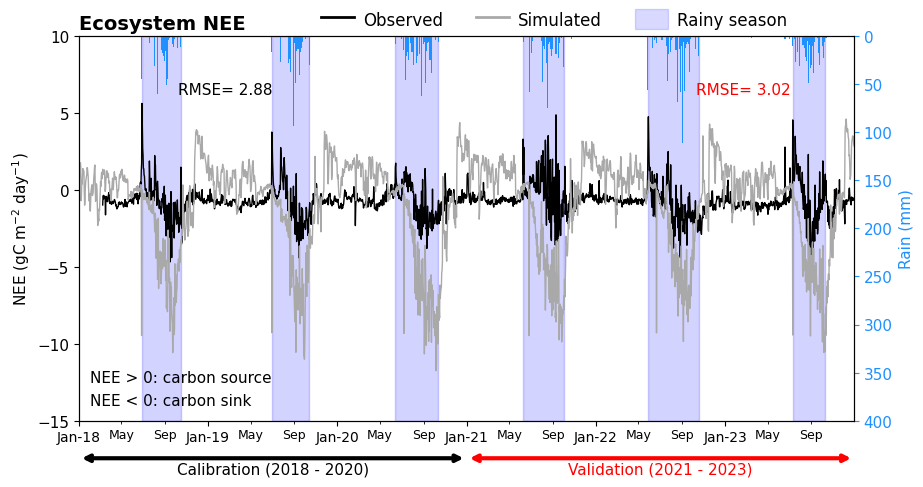

In [42]:


# Define color
color_obs = 'black'
color_sim = 'darkgrey'
color_rain = '#1E90FF'
line_weight = 1

# Identify the start and end dates for the rainy season each year
rainy_seasons = []
for year, group in df2.groupby(df2.index.year):
    first_rain_dates = group[group['Rain'] > 5].index
    last_rain_dates = group[group['Rain'] > 5].index
    if not first_rain_dates.empty:
        start_date = first_rain_dates.min()
        end_date = last_rain_dates.max()
        rainy_seasons.append((start_date, end_date))

# Create the plots with shared x-axis
fig, ax = plt.subplots(figsize=(10, 5))

# Add the inverted Rain on the secondary y-axis
ax3 = ax.twinx()
ax3.invert_yaxis()
ax3.bar(df2.index, df2['Rain'], width=3, color=color_rain, label='Rain (mm)')

# Highlight the rainy periods
for start, end in rainy_seasons:
    ax.axvspan(start, end, color='blue', alpha=0.09)
    ax.axvspan(start, end, color='blue', alpha=0.09)

# Plot LAI_Crop_obs and LAI_Crop_orch on the first subplot
line1, = ax.plot(df2.index, df2['NEE_ecosys_obs'], lw=line_weight, color=color_obs)
line2, = ax.plot(df2.index, df2['NEE_ecosys_orch'], lw=line_weight, color=color_sim)



a_lim = df2.index.min() + pd.Timedelta(days=280)
b_lim = df2.index.max() - pd.Timedelta(days=180)
# Add MRMSE indicators

ax.text(a_lim, 7, f"RMSE= {results['Calibration NEE_ecosys']['RMSE']:.2f}",
         color='black', fontsize=11, va='top', ha='left')
ax.text(b_lim, 7, f"RMSE= {results['Validation NEE_ecosys']['RMSE']:.2f}",
         color='red', fontsize=11, va='top', ha='right')


# Set labels and title for the first subplot
ax.set_ylabel('NEE (gC m$^{-2}$ day$^{-1}$)', fontsize=11)
ax3.set_ylabel('Rain (mm)', color=color_rain, fontsize=11)
ax3.tick_params(axis='y', colors=color_rain, labelsize=11)
ax3.set_ylim(400, 0)
# ax.set_yticks(np.arange(0, 20, 4)) 
ax.set_ylim(-15, 10)


# Create a patch for the rainy season
rain_patch = Patch(color='blue', alpha=0.15, label='Rainy season')

# Create lines for 'Observed' and 'Simulated'
line1 = Line2D([0], [0], color=color_obs, lw=2, label='Observed')  # lw (linewidth) = 2 for smaller line width
line2 = Line2D([0], [0], color=color_sim, lw=2, label='Simulated')

ax.set_title('Ecosystem NEE', loc='left', pad=5, size=14, weight='bold')
ax.text(df2.index.min() + pd.Timedelta(days=30), -12.5,'NEE > 0: carbon source', fontsize=11)
ax.text(df2.index.min() + pd.Timedelta(days=30), -14,'NEE < 0: carbon sink', fontsize=11)
# Add a legend for the lines and patch
fig.legend([line1, line2, rain_patch],
           ['Observed', 'Simulated', 'Rainy season'],
           loc='upper center', ncol=3, bbox_to_anchor=(0.6, 0.95), frameon=False, 
           fontsize=12,
           handlelength=2,         
           handleheight=1.5,       
           labelspacing=2.0,       
           borderpad=0.0,          
           handletextpad=0.5)


ax.set_xlim(df2.index.min(), df2.index.max())


# Set x-axis ticks for Jan, May, and Sept
ax.xaxis.set_major_locator(YearLocator())
ax.xaxis.set_minor_locator(MonthLocator(bymonth=[1, 5, 9]))
ax.xaxis.set_major_formatter(DateFormatter("%Y"))
ax.xaxis.set_minor_formatter(DateFormatter("%b"))
# ax1.set_xlabel('Date', fontsize=11)

# Update tick label sizes
ax.tick_params(axis='x', which='major', labelsize=10)
ax.tick_params(axis='x', which='minor', labelsize=9)
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# Date formatter for minor ticks
date_form = DateFormatter("%b-%y")
ax.xaxis.set_major_formatter(date_form)

# Create an additional axes at the bottom for drawing the arrows
bbox = ax.get_position()
arrow_ax = fig.add_axes([bbox.x0, 0.01, bbox.width, 0.05])  # Align with ax1
arrow_ax.axis('off')

# Define start and end dates for the arrows
start_date_black = pd.Timestamp('2018-01-01')
end_date_black = pd.Timestamp('2020-12-31')
start_date_red = pd.Timestamp('2021-01-01')
end_date_red = pd.Timestamp('2023-12-31')

# Draw arrows using date positions directly on the new axis
arrow_ax.annotate('', xy=(start_date_black, 0.5), xytext=(end_date_black, 0.5),
                  arrowprops=dict(arrowstyle='<->', color='black', linewidth=3),
                  xycoords='data', textcoords='data', annotation_clip=False)

arrow_ax.annotate('', xy=(start_date_red, 0.5), xytext=(end_date_red, 0.5),
                  arrowprops=dict(arrowstyle='<->', color='red', linewidth=3),
                  xycoords='data', textcoords='data', annotation_clip=False)

# Compute the midpoints and add text below the arrows
mid_black = start_date_black + (end_date_black - start_date_black) / 2
mid_red = start_date_red + (end_date_red - start_date_red) / 2

arrow_ax.text(mid_black, 0.05, 'Calibration (2018 - 2020)',
              color='black', ha='center', va='center', fontsize=11)

arrow_ax.text(mid_red, 0.05, 'Validation (2021 - 2023)',
              color='red', ha='center', va='center', fontsize=11)

arrow_ax.set_xlim(df2.index.min(), df2.index.max())

plt.show()

### Plot LE, H and Rn

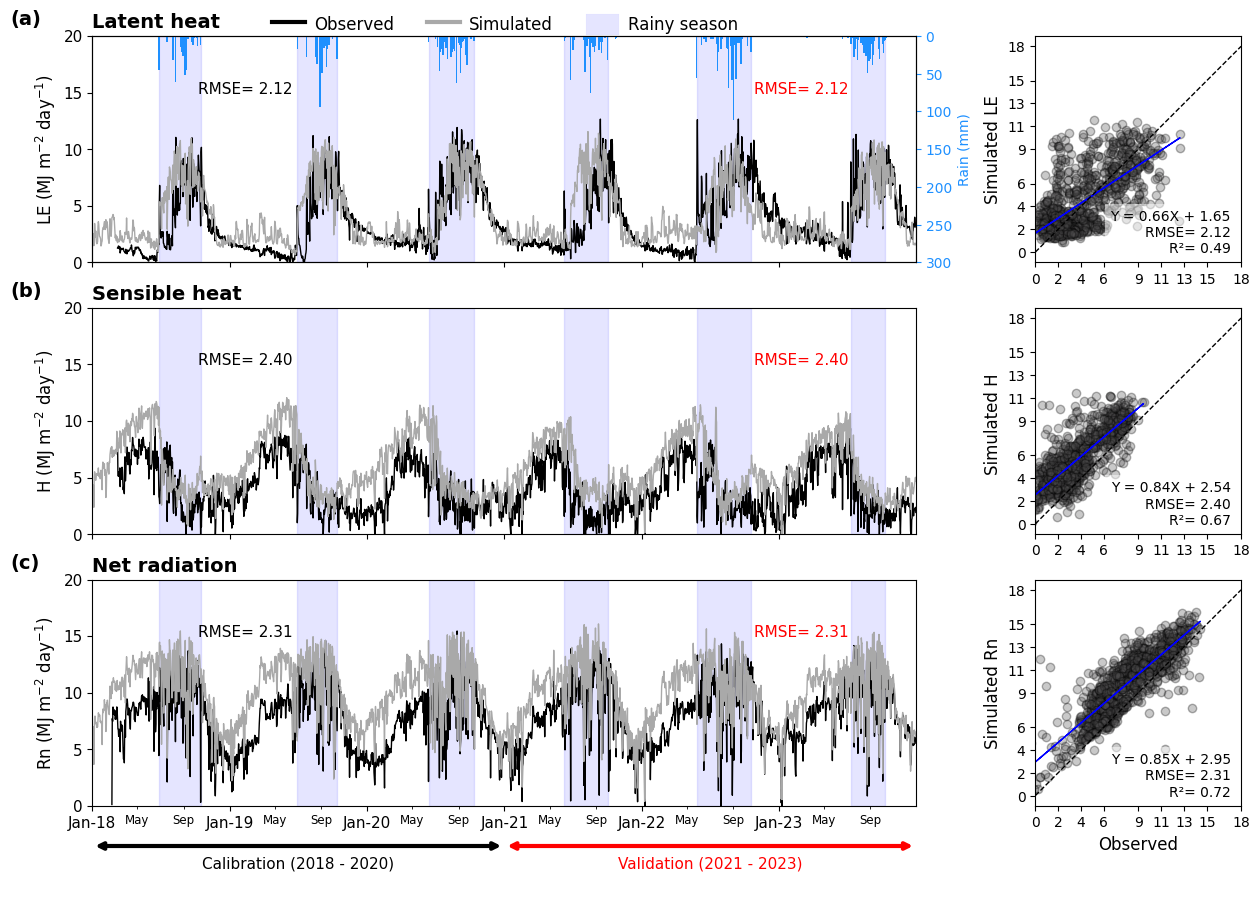

In [15]:

# Variables and units
variables_to_plot = [('LE_ecosys_obs', 'LE_ecosys_orch'), ('H_ecosys_obs', 'H_ecosys_orch'),
                     ('Rn_ecosys_obs', 'Rn_ecosys_orch')]
units = ["LE (MJ m$^{-2}$ day$^{-1}$)", "H (MJ m$^{-2}$ day$^{-1}$)", "Rn (MJ m$^{-2}$ day$^{-1}$)"]

names_variables_to_plot = ["Latent heat", "Sensible heat", "Net radiation"]

color_obs = 'black'
color_sim = 'darkgrey'
color_rain = '#1E90FF'
line_weight = 1

rainy_seasons = []
for year, group in df2.groupby(df2.index.year):
    first_rain_dates = group[group['Rain'] > 5].index
    last_rain_dates = group[group['Rain'] > 5].index
    if not first_rain_dates.empty:
        start_date = first_rain_dates.min()
        end_date = last_rain_dates.max()
        rainy_seasons.append((start_date, end_date))

# Create subplots for each variable
fig, axes = plt.subplots(len(variables_to_plot), 2, figsize=(15, 10), gridspec_kw={'width_ratios': [3, 0.85]})

for i, (var1, var2) in enumerate(variables_to_plot):
    ax1 = axes[i, 0]  # Left axis for line plot
    ax2 = axes[i, 1]  # Right axis for scatter plot
    
    obs = validation_data[var1]
    sim = validation_data[var2]

    if i == 0:
        ax3 = ax1.twinx()
        ax3.invert_yaxis()
        ax3.bar(df2.index, df2['Rain'], width=4, color=color_rain, label='Rain (mm)')
        ax3.set_ylabel('Rain (mm)', color=color_rain)
        ax3.tick_params(axis='y', colors=color_rain)
        ax3.set_ylim(300,0)

    # Highlight the rainy periods
    for start, end in rainy_seasons:
        ax1.axvspan(start, end, color='blue', alpha=0.1)

    # Add subplot annotation
    axes[i, 0].text(-0.1, 1.05, f'({chr(97 + i)})', transform=axes[i, 0].transAxes, size=14, weight='bold')
    a_lim = df2.index.min() + pd.Timedelta(days=280)
    b_lim = df2.index.max() - pd.Timedelta(days=180)
    
    ax1.text(a_lim, 16, f"RMSE= {results['Validation '+ var1[:-4]]['RMSE']:.2f}",
         color='black', fontsize=11, va='top', ha='left')
    ax1.text(b_lim, 16, f"RMSE= {results['Validation '+ var1[:-4]]['RMSE']:.2f}",
            color='red', fontsize=11, va='top', ha='right')

    line1, = ax1.plot(df2.index, df2[var1], color=color_obs, label='Observed', lw=line_weight)
    line2, = ax1.plot(df2.index, df2[var2], color=color_sim, label='Simulated', lw=line_weight)
    ax1.set_title(names_variables_to_plot[i], fontsize=14, loc="left", fontweight='bold')
    ax1.set_ylabel(f'{units[i]}', fontsize=12)

    ax2.scatter(obs, sim, color="#4f4e4f", alpha=0.3, edgecolor='black')
    
    slope, intercept, r_value, p_value, std_err = linregress(obs, sim)
    
    ax2.plot(obs, slope * obs + intercept, color="blue", linewidth=1)

    ax2.plot([0, 18], [0, 18], 'k--', lw=1)

    sign = '-' if intercept < 0 else '+'

    ax1.set_xlim(df2.index.min(), df2.index.max())
    ax1.tick_params(axis='x', which='major', labelsize=11)
    ax1.tick_params(axis='x', which='minor', labelsize=8.5)
    ax1.tick_params(axis='y', labelsize=11)
    
    ax1.set_ylim(0, 20)
    ax2.set_xlim(0, 18)
    ax1.set_yticks(np.floor(np.linspace(0, 20, 5)))
    
    ax2.set_xticks(np.floor(np.linspace(0, 18, 9)))
    ax2.set_yticks(np.floor(np.linspace(0, 18, 9)))
    ax2.set_aspect('equal', adjustable='box')
    ax2.set_xlabel(f'Observed', fontsize=11)
    ax2.set_ylabel(f'Simulated {units[i][:2]}', fontsize=12)
    date_form = DateFormatter("%b-%y")

    # Additional metrics text
    metrics_text = f"Y = {slope:.2f}X {sign} {abs(intercept):.2f}\n"\
                f"RMSE= {results['Validation '+ var1[:-4]]['RMSE']:.2f}\n" \
                f"R²= {results['Validation ' + var1[:-4]]['R-squared']:.2f}"
                
    ax2.text(0.95, 0.03, metrics_text, fontsize=10, va='bottom', ha='right', 
            transform=ax2.transAxes, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

    if i != len(variables_to_plot) - 1:
        ax1.set_xlabel('')
        ax1.set_xticklabels([])
        ax2.set_xlabel('')
    else:
        ax1.xaxis.set_major_locator(YearLocator())
        ax1.xaxis.set_minor_locator(MonthLocator(bymonth=[1, 5, 9]))
        ax1.xaxis.set_major_formatter(DateFormatter("%Y"))
        ax1.xaxis.set_minor_formatter(DateFormatter("%b"))
        ax1.xaxis.set_major_formatter(date_form)
        ax1.tick_params(axis='y', labelsize=11)
        ax2.set_xlabel(f'Observed', fontsize=12)

rain_patch = Patch(color='blue', alpha=0.1, label='Rainy season', linewidth=0.1)
legend_lines = [Line2D([0], [0], color=color_obs, linewidth=3),
                Line2D([0], [0], color=color_sim, linewidth=3),
                rain_patch]
fig.legend(legend_lines, ['Observed', 'Simulated', 'Rainy season'],
           loc='upper center', ncol=3, fontsize=12, bbox_to_anchor=(0.4, 0.91), 
           frameon=False,     
           handlelength=2,         
           handleheight=1.5,       
           labelspacing=1.0,       
           borderpad=0.0,          
           handletextpad=0.5       
           )

# Create an additional axes at the bottom for drawing the arrows
bbox = ax1.get_position()
arrow_ax = fig.add_axes([bbox.x0, 0.01, bbox.width, 0.12])  # Align with ax1
arrow_ax.axis('off')

# Define start and end dates for the arrows
start_date_black = pd.Timestamp('2018-01-01')
end_date_black = pd.Timestamp('2020-12-31')
start_date_red = pd.Timestamp('2021-01-01')
end_date_red = pd.Timestamp('2023-12-31')

# Draw arrows using date positions directly on the new axis
arrow_ax.annotate('', xy=(start_date_black, 0.5), xytext=(end_date_black, 0.5),
                  arrowprops=dict(arrowstyle='<->', color='black', linewidth=3),
                  xycoords='data', textcoords='data', annotation_clip=False)

arrow_ax.annotate('', xy=(start_date_red, 0.5), xytext=(end_date_red, 0.5),
                  arrowprops=dict(arrowstyle='<->', color='red', linewidth=3),
                  xycoords='data', textcoords='data', annotation_clip=False)

# Compute the midpoints and add text below the arrows
mid_black = start_date_black + (end_date_black - start_date_black) / 2
mid_red = start_date_red + (end_date_red - start_date_red) / 2

arrow_ax.text(mid_black, 0.35, 'Calibration (2018 - 2020)',
              color='black', ha='center', va='center', fontsize=11)

arrow_ax.text(mid_red, 0.35, 'Validation (2021 - 2023)',
              color='red', ha='center', va='center', fontsize=11)

arrow_ax.set_xlim(df2.index.min(), df2.index.max())

# plt.subplots_adjust(hspace=0.2, wspace=0.1)
plt.show()

### Plot Reco

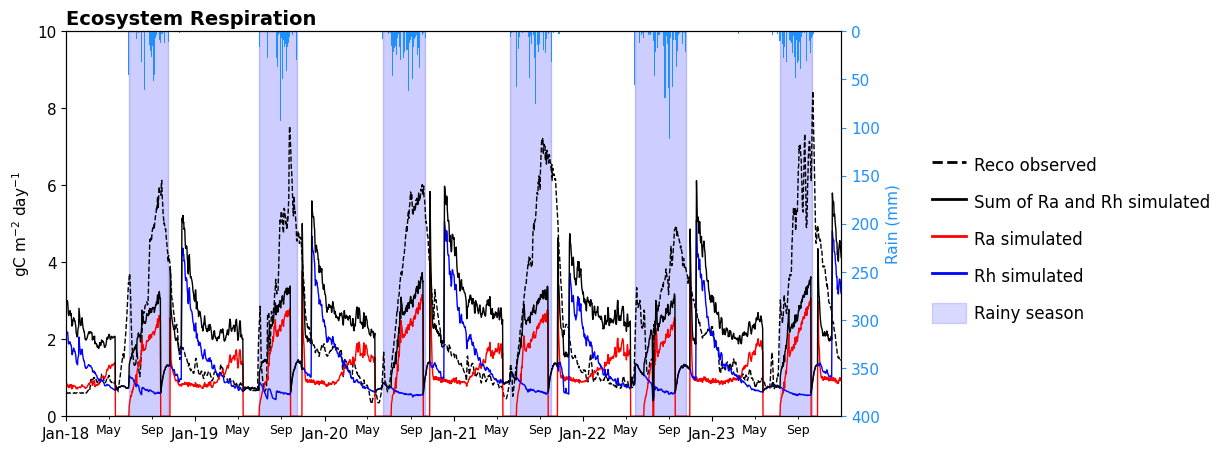

In [11]:


# Define color
color_obs = 'black'
color_sim = 'darkgrey'
color_rain = '#1E90FF'
line_weight = 1

# Identify the start and end dates for the rainy season each year
rainy_seasons = []
for year, group in df2.groupby(df2.index.year):
    first_rain_dates = group[group['Rain'] > 5].index
    last_rain_dates = group[group['Rain'] > 5].index
    if not first_rain_dates.empty:
        start_date = first_rain_dates.min()
        end_date = last_rain_dates.max()
        rainy_seasons.append((start_date, end_date))

# Create the plots with shared x-axis
fig, ax = plt.subplots(figsize=(10, 5))

# Add the inverted Rain on the secondary y-axis
ax3 = ax.twinx()
ax3.invert_yaxis()
ax3.bar(df2.index, df2['Rain'], width=3, color=color_rain, label='Rain (mm)')

# Highlight the rainy periods
for start, end in rainy_seasons:
    ax.axvspan(start, end, color='blue', alpha=0.1)
    ax.axvspan(start, end, color='blue', alpha=0.1)

# Plot LAI_Crop_obs and LAI_Crop_orch on the first subplot
line1, = ax.plot(df2.index, df2['Reco_ecosys_obs'], "k--", lw=line_weight, label="Reco observed")
line2, = ax.plot(df2.index, df2['Ra_ecosys_orch'], "r", lw=line_weight, label="Ra simulated")
line3, = ax.plot(df2.index, df2['Rh_ecosys_orch'], "b", lw=line_weight, label="Rh simulated")
line4, = ax.plot(df2.index, df2['Sum_Ra_Rh_ecosys_orch'], "k", lw=line_weight, label="Sum of Ra and Rh simulated")


a_lim = df2.index.min() + pd.Timedelta(days=280)
b_lim = df2.index.max() - pd.Timedelta(days=180)
# Add MRMSE indicators

# Set labels and title for the first subplot
ax.set_ylabel('gC m$^{-2}$ day$^{-1}$', fontsize=11)
ax3.set_ylabel('Rain (mm)', color=color_rain, fontsize=11)
ax3.tick_params(axis='y', colors=color_rain, labelsize=11)
ax3.set_ylim(400, 0)
# ax.set_yticks(np.arange(0, 20, 4)) 
ax.set_ylim(0, 10)


# Create a patch for the rainy season
rain_patch = Patch(color='blue', alpha=0.15, label='Rainy season')

# Create lines for 'Observed' and 'Simulated'
line1 = Line2D([0], [0], color="black", lw=2, ls="--", label='Reco observed')  # lw (linewidth) = 2 for smaller line width
line2 = Line2D([0], [0], color="red", lw=2, label='Ra simulated')
line3 = Line2D([0], [0], color="blue", lw=2, label='Rh simulated')
line4 = Line2D([0], [0], color="black", lw=2, label='Sum of Ra and Rh simulated')

ax.set_title('Ecosystem Respiration', loc='left', pad=5, size=14, weight='bold')

# Add a legend for the lines and patch
fig.legend([line1, line4, line2, line3, rain_patch],
           ["Reco observed", "Sum of Ra and Rh simulated", "Ra simulated", "Rh simulated", "Rainy season"],
           loc='upper center', ncol=1, bbox_to_anchor=(1.13, 0.65), frameon=False, 
           fontsize=12,
           handlelength=2,         
           handleheight=1.5,       
           labelspacing=1.0,       
           borderpad=0.0,          
           handletextpad=0.5)


ax.set_xlim(df2.index.min(), df2.index.max())


# Set x-axis ticks for Jan, May, and Sept
ax.xaxis.set_major_locator(YearLocator())
ax.xaxis.set_minor_locator(MonthLocator(bymonth=[1, 5, 9]))
ax.xaxis.set_major_formatter(DateFormatter("%Y"))
ax.xaxis.set_minor_formatter(DateFormatter("%b"))
# ax1.set_xlabel('Date', fontsize=11)

# Update tick label sizes
ax.tick_params(axis='x', which='major', labelsize=11)
ax.tick_params(axis='x', which='minor', labelsize=9)
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# Date formatter for minor ticks
date_form = DateFormatter("%b-%y")
ax.xaxis.set_major_formatter(date_form)

plt.show()

### Anomalies 

In [113]:
df3 = pd.read_excel("Data_source_paper_biogeosciences.xlsx", sheet_name="SimWaterPlot")

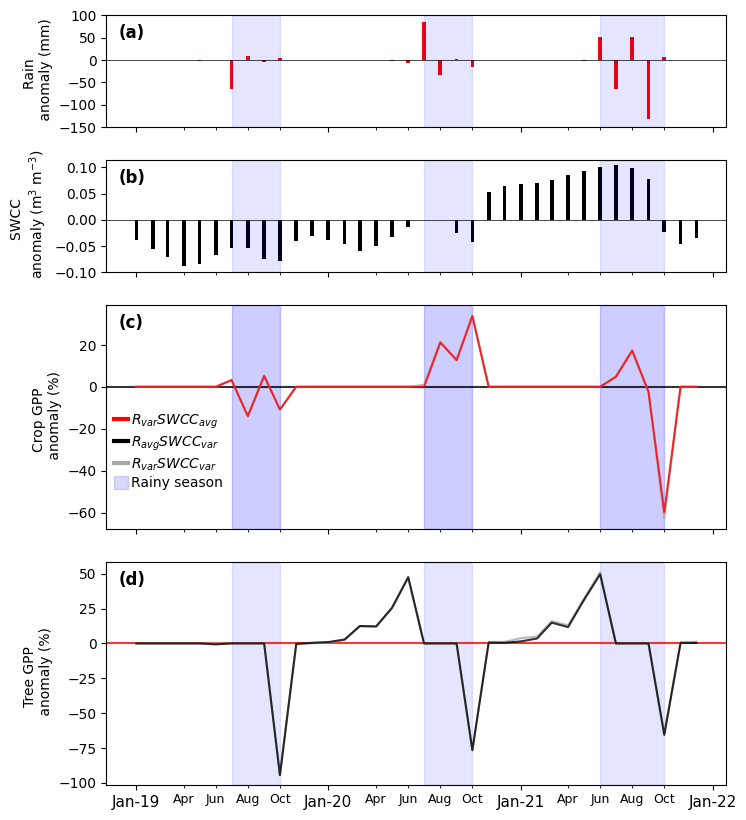

In [146]:
import matplotlib.dates as mdates
from matplotlib.dates import YearLocator, MonthLocator, DateFormatter
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as patches

data = df3.copy()
# Create a dictionary to map month names to numbers
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

# Map the 'Month' column to its numeric equivalent
data['Month'] = data['Month'].map(month_map)

# Now create the 'Date' column
data['Date'] = pd.to_datetime(data[['Year', 'Month']].assign(DAY=1))
# Assuming 'data' dataframe is already available
anoR = data['Ano_Rain']
anoGW = data['Ano_SWCC']
gppCrop = data["R_varSWCC_avg_gppCrop_%"]
gppTree = data['R_avgSWCC_var_gppTree_%']
# gppEcosys = data['R_varSWCC_var_gppEcosys_%']
gppCropVarfull = data['R_varSWCC_var_gppCrop_%']
gppTreeVarfull = data['R_varSWCC_var_gppTree_%']


fig, axs = plt.subplots(4, 1, figsize=(8, 10), sharex=True, 
                        gridspec_kw={'height_ratios': [1, 1, 2, 2]})

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.2)  # Increase this value for more space

color_rain = "red"
color_swcc = "black"
color_all = "darkgrey"
# Plot AnoR as a barplot on the first axis
axs[0].bar(data['Date'], anoR, color='red', label='AnoR', width=7)
axs[0].set_ylabel('Rain \n anomaly (mm)')
# axs[0].set_title('Rainfall anomaly', loc='left', pad=5, size=11)
axs[0].axhline(0, color='black', linestyle='-', lw=0.5)
axs[0].axvspan(pd.Timestamp('2019-07-01'), pd.Timestamp('2019-10-01'), color='blue', alpha=0.1)
axs[0].axvspan(pd.Timestamp('2020-07-01'), pd.Timestamp('2020-10-01'), color='blue', alpha=0.1)
axs[0].axvspan(pd.Timestamp('2021-06-01'), pd.Timestamp('2021-10-01'), color='blue', alpha=0.1)
axs[0].set_yticks([-150., -100, -50., 0., 50., 100.])

axs[0].text(0.02, 0.8, f'({chr(97)})', transform=axs[0].transAxes, size=12, weight='bold')
axs[1].text(0.02, 0.8, f'({chr(98)})', transform=axs[1].transAxes, size=12, weight='bold')
axs[2].text(0.02, 0.9, f'({chr(99)})', transform=axs[2].transAxes, size=12, weight='bold')
axs[3].text(0.02, 0.9, f'({chr(100)})', transform=axs[3].transAxes, size=12, weight='bold')

# Create a patch for the rainy season
# rain_patch = Patch(color='blue', alpha=0.15, label='Rainy season')
# # Add a legend for the lines and patch
# axs[2].legend([rain_patch],
#            ["Rainy season"],
#            loc='upper center', ncol=1, bbox_to_anchor=(0.9, 1.12), frameon=False, 
#            fontsize=11,
#            handlelength=2,         
#            handleheight=1.0,       
#            labelspacing=1.0,       
#            borderpad=0.0,          
#            handletextpad=0.5)

# Plot AnoGW as a barplot on the second axis
axs[1].bar(data['Date'], anoGW, color='black', label='AnoGW', width=7)
axs[1].set_ylabel('SWCC \n anomaly (m$^{3}$ m$^{-3}$)')
# axs[1].set_title('SWCC anomaly', loc='left', pad=5, size=11)
axs[1].axhline(0, color='black', linestyle='-', lw=0.5)
axs[1].axvspan(pd.Timestamp('2019-07-01'), pd.Timestamp('2019-10-01'), color='blue', alpha=0.1)
axs[1].axvspan(pd.Timestamp('2020-07-01'), pd.Timestamp('2020-10-01'), color='blue', alpha=0.1)
axs[1].axvspan(pd.Timestamp('2021-06-01'), pd.Timestamp('2021-10-01'), color='blue', alpha=0.1)
axs[1].set_yticks([-0.1, -0.05, 0., 0.05, 0.1])

# axs[2].set_ylim([-70., 90])
# axs[2].set_yticks([-70., -30., 0., 30., 60., 90])

# axs[3].set_ylim([-105., 100])
# axs[3].set_yticks([-105., -50., 0., 50., 100])

# Set the general title part without the colored sections
# axs[2].set_title('Crop GPP '+ r'(     ${R_{var}SWCC_{avg}}$)'+ '     Crop GPP ' + r'(     ${R_{var}SWCC_{var}}$)', loc='left', pad=5, size=11)

# # Set the general title part without the colored sections
# axs[3].set_title('Tree GPP '+ r'(     ${R_{avg}SWCC_{var}}$)'+ '     Tree GPP ' + r'(     ${R_{var}SWCC_{var}}$)', loc='left', pad=5, size=11)

# # # Add red band as a rectangle behind the first math expression
# red_band = patches.Rectangle((0.14, 1.05), 0.025, 0.01, transform=axs[2].transAxes, 
#                              color=color_rain, clip_on=False)
# axs[2].add_patch(red_band)

# gray_band = patches.Rectangle((0.505, 1.05), 0.025, 0.01, transform=axs[2].transAxes, 
#                              color=color_all, clip_on=False)
# axs[2].add_patch(gray_band)

# black_band = patches.Rectangle((0.14, 1.05), 0.025, 0.01, transform=axs[3].transAxes, 
#                              color=color_swcc, clip_on=False)
# axs[3].add_patch(black_band)

# gray_band = patches.Rectangle((0.505, 1.05), 0.025, 0.01, transform=axs[3].transAxes, 
#                              color=color_all, clip_on=False)
# axs[3].add_patch(gray_band)

# # Plot GPP on the third axis
axs[2].axhline(0, color='black', linestyle='-', lw=1.5, alpha=0.8)
axs[2].plot(data['Date'], gppCropVarfull, label='gppEcosys', color='darkgrey', alpha=0.8)
axs[2].plot(data['Date'], gppCrop, label='gppCrop', color='red', alpha=0.8)


axs[3].axhline(0, color='red', linestyle='-', lw=1.5, alpha=0.8)
axs[3].plot(data['Date'], gppTreeVarfull, label='gppEcosys', color='darkgrey', alpha=0.8)
axs[3].plot(data['Date'], gppTree, label='gppTree', color='black', alpha=0.8)

rain_patch = Patch(color='blue', alpha=0.15, label='Rainy season')
legend_lines = [Line2D([0], [0], color="red", linewidth=3),
                Line2D([0], [0], color="black", linewidth=3),
                Line2D([0], [0], color="darkgrey", linewidth=3), rain_patch]
axs[2].legend(legend_lines, [r'${R_{var}SWCC_{avg}}$', r'${R_{avg}SWCC_{var}}$', r'${R_{var}SWCC_{var}}$',"Rainy season"],
           loc='upper center', ncol=1, fontsize=10, bbox_to_anchor=(0.10, 0.55), 
           frameon=False,     
           handlelength=1,         
           handleheight=1.,       
           labelspacing=0.25,       
           borderpad=0.0,          
           handletextpad=0.25)

axs[2].set_ylabel('Crop GPP \n anomaly (%)')
axs[3].set_ylabel('Tree GPP \n anomaly (%)')

axs[2].axvspan(pd.Timestamp('2019-07-01'), pd.Timestamp('2019-10-01'), color='blue', alpha=0.1)
axs[2].axvspan(pd.Timestamp('2020-07-01'), pd.Timestamp('2020-10-01'), color='blue', alpha=0.1)
axs[2].axvspan(pd.Timestamp('2021-06-01'), pd.Timestamp('2021-10-01'), color='blue', alpha=0.1)
axs[3].axvspan(pd.Timestamp('2019-07-01'), pd.Timestamp('2019-10-01'), color='blue', alpha=0.1)
axs[3].axvspan(pd.Timestamp('2020-07-01'), pd.Timestamp('2020-10-01'), color='blue', alpha=0.1)
axs[3].axvspan(pd.Timestamp('2021-06-01'), pd.Timestamp('2021-10-01'), color='blue', alpha=0.1)
axs[2].axvspan(pd.Timestamp('2019-07-01'), pd.Timestamp('2019-10-01'), color='blue', alpha=0.1)
axs[2].axvspan(pd.Timestamp('2020-07-01'), pd.Timestamp('2020-10-01'), color='blue', alpha=0.1)
axs[2].axvspan(pd.Timestamp('2021-06-01'), pd.Timestamp('2021-10-01'), color='blue', alpha=0.1)


# # Formatting x-axis
axs[3].xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
axs[3].xaxis.set_major_locator(YearLocator())
axs[3].xaxis.set_minor_locator(MonthLocator(bymonth=[1, 4, 6, 8, 10]))
axs[3].xaxis.set_major_formatter(DateFormatter("%Y"))
axs[3].xaxis.set_minor_formatter(DateFormatter("%b"))
axs[3].tick_params(axis='y', labelsize=10)
axs[3].tick_params(axis='x', which='major', labelsize=11)
axs[3].tick_params(axis='x', which='minor', labelsize=9)

# Date formatter for minor ticks
date_form = DateFormatter("%b-%y")
axs[3].xaxis.set_major_formatter(date_form)

# Show the plots
plt.show()

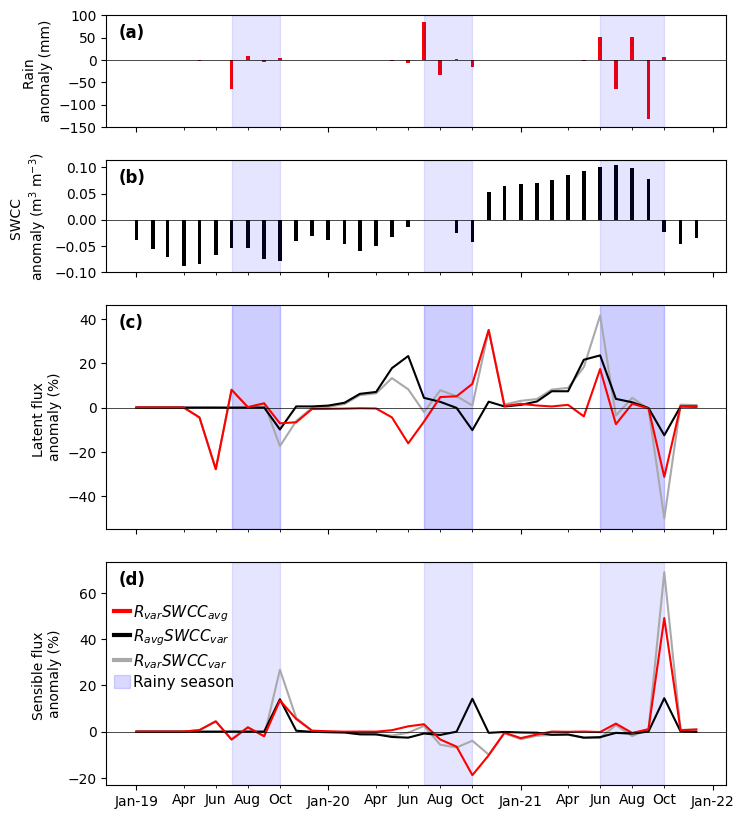

In [152]:
import matplotlib.dates as mdates
from matplotlib.dates import YearLocator, MonthLocator, DateFormatter
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as patches

data = df3.copy()
# Create a dictionary to map month names to numbers
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

# Map the 'Month' column to its numeric equivalent
data['Month'] = data['Month'].map(month_map)

# Now create the 'Date' column
data['Date'] = pd.to_datetime(data[['Year', 'Month']].assign(DAY=1))
# Assuming 'data' dataframe is already available
anoR = data['Ano_Rain']
anoGW = data['Ano_SWCC']


lat_robs = data["R_varSWCC_avg_fluxlat_%"]
lat_gwobs = data['R_avgSWCC_var_fluxlat_%']
lat_robs_gwobs = data['R_varSWCC_var_fluxlat_%']

sens_robs = data["R_varSWCC_avg_fluxsens_%"]
sens_gwobs = data['R_avgSWCC_var_fluxsens_%']
sens_robs_gwobs = data['R_varSWCC_var_fluxsens_%']

fig, axs = plt.subplots(4, 1, figsize=(8, 10), sharex=True, 
                        gridspec_kw={'height_ratios': [1, 1, 2, 2]})

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.2)  # Increase this value for more space

color_rain = "red"
color_swcc = "black"
color_all = "darkgrey"
# Plot AnoR as a barplot on the first axis
axs[0].bar(data['Date'], anoR, color='red', label='AnoR', width=7)
axs[0].set_ylabel('Rain \nanomaly (mm)')
# axs[0].set_title('Rainfall anomaly', loc='left', pad=5, size=11)
axs[0].axhline(0, color='black', linestyle='-', lw=0.5)
axs[0].axvspan(pd.Timestamp('2019-07-01'), pd.Timestamp('2019-10-01'), color='blue', alpha=0.1)
axs[0].axvspan(pd.Timestamp('2020-07-01'), pd.Timestamp('2020-10-01'), color='blue', alpha=0.1)
axs[0].axvspan(pd.Timestamp('2021-06-01'), pd.Timestamp('2021-10-01'), color='blue', alpha=0.1)
axs[0].set_yticks([-150., -100, -50., 0., 50., 100.])

# Plot AnoGW as a barplot on the second axis
axs[1].bar(data['Date'], anoGW, color='black', label='AnoGW', width=7)
axs[1].set_ylabel('SWCC \nanomaly (m$^{3}$ m$^{-3}$)')
# axs[1].set_title('SWCC anomaly', loc='left', pad=5, size=11)
axs[1].axhline(0, color='black', linestyle='-', lw=0.5)
axs[1].axvspan(pd.Timestamp('2019-07-01'), pd.Timestamp('2019-10-01'), color='blue', alpha=0.1)
axs[1].axvspan(pd.Timestamp('2020-07-01'), pd.Timestamp('2020-10-01'), color='blue', alpha=0.1)
axs[1].axvspan(pd.Timestamp('2021-06-01'), pd.Timestamp('2021-10-01'), color='blue', alpha=0.1)
axs[1].set_yticks([-0.1, -0.05, 0., 0.05, 0.1])


# # Set the general title part without the colored sections
# axs[2].set_title('Latent flux', loc='left', pad=5, size=11)
# axs[3].set_title('Sensible flux', loc='left', pad=5, size=11)


# # Plot GPP on the third axis
axs[2].plot(data['Date'], lat_robs_gwobs, label='R_varSWCC_var_fluxlat', color='darkgrey')
axs[2].plot(data['Date'], lat_gwobs, label='R_avgSWCC_var_fluxlat', color='black')
axs[2].plot(data['Date'], lat_robs, label='R_varSWCC_avg_fluxlat', color='red')

axs[2].axhline(0, color='black', linestyle='-', lw=0.5)

axs[3].plot(data['Date'], sens_robs_gwobs, label='R_varSWCC_var_fluxlat', color='darkgrey')
axs[3].plot(data['Date'], sens_gwobs, label='R_avgSWCC_var_fluxlat', color='black')
axs[3].plot(data['Date'], sens_robs, label='R_varSWCC_avg_fluxlat', color='red')

axs[3].axhline(0, color='black', linestyle='-', lw=0.5)


axs[2].set_ylabel('Latent flux \nanomaly (%)')
axs[3].set_ylabel('Sensible flux \nanomaly (%)')
# axs[2].legend(loc='upper right')
axs[2].axvspan(pd.Timestamp('2019-07-01'), pd.Timestamp('2019-10-01'), color='blue', alpha=0.1)
axs[2].axvspan(pd.Timestamp('2020-07-01'), pd.Timestamp('2020-10-01'), color='blue', alpha=0.1)
axs[2].axvspan(pd.Timestamp('2021-06-01'), pd.Timestamp('2021-10-01'), color='blue', alpha=0.1)
axs[3].axvspan(pd.Timestamp('2019-07-01'), pd.Timestamp('2019-10-01'), color='blue', alpha=0.1)
axs[3].axvspan(pd.Timestamp('2020-07-01'), pd.Timestamp('2020-10-01'), color='blue', alpha=0.1)
axs[3].axvspan(pd.Timestamp('2021-06-01'), pd.Timestamp('2021-10-01'), color='blue', alpha=0.1)
axs[2].axvspan(pd.Timestamp('2019-07-01'), pd.Timestamp('2019-10-01'), color='blue', alpha=0.1)
axs[2].axvspan(pd.Timestamp('2020-07-01'), pd.Timestamp('2020-10-01'), color='blue', alpha=0.1)
axs[2].axvspan(pd.Timestamp('2021-06-01'), pd.Timestamp('2021-10-01'), color='blue', alpha=0.1)

axs[0].text(0.02, 0.8, f'({chr(97)})', transform=axs[0].transAxes, size=12, weight='bold')
axs[1].text(0.02, 0.8, f'({chr(98)})', transform=axs[1].transAxes, size=12, weight='bold')
axs[2].text(0.02, 0.9, f'({chr(99)})', transform=axs[2].transAxes, size=12, weight='bold')
axs[3].text(0.02, 0.9, f'({chr(100)})', transform=axs[3].transAxes, size=12, weight='bold')

# # Formatting x-axis
axs[3].xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
axs[3].xaxis.set_major_locator(YearLocator())
axs[3].xaxis.set_minor_locator(MonthLocator(bymonth=[1, 4, 6, 8, 10]))
axs[3].xaxis.set_major_formatter(DateFormatter("%Y"))
axs[3].xaxis.set_minor_formatter(DateFormatter("%b"))
axs[3].tick_params(axis='y', labelsize=10)
axs[3].tick_params(axis='x', labelsize=10)
# Date formatter for minor ticks
date_form = DateFormatter("%b-%y")
axs[3].xaxis.set_major_formatter(date_form)
from matplotlib.lines import Line2D
rain_patch = Patch(color='blue', alpha=0.15, label='Rainy season')
legend_lines = [Line2D([0], [0], color="red", linewidth=3),
                Line2D([0], [0], color="black", linewidth=3),
                Line2D([0], [0], color="darkgrey", linewidth=3), rain_patch]
axs[3].legend(legend_lines, [r'${R_{var}SWCC_{avg}}$', r'${R_{avg}SWCC_{var}}$', r'${R_{var}SWCC_{var}}$',"Rainy season"],
           loc='upper center', ncol=1, fontsize=11, bbox_to_anchor=(0.11, 0.85), 
           frameon=False,     
           handlelength=1,         
           handleheight=1.,       
           labelspacing=0.25,       
           borderpad=0.0,          
           handletextpad=0.25)

# # Create a patch for the rainy season
# rain_patch = Patch(color='blue', alpha=0.15, label='Rainy season')
# # Add a legend for the lines and patch
# fig.legend([rain_patch],
#            ["Rainy season"],
#            loc='upper center', ncol=1, bbox_to_anchor=(0.5, 0.906), frameon=False, 
#            fontsize=11,
#            handlelength=2,         
#            handleheight=1.0,       
#            labelspacing=1.0,       
#            borderpad=0.0,          
#            handletextpad=0.5)

# Align the x-axis labels and improve plot aesthetics
# plt.tight_layout()

# Show the plots
plt.show()